<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana11/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A carregar o dataset real de Vinhos Italianos...
Tamanho da Base: 178 registos e 13 características químicas.



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


,Tipo_Vinho
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


,count
Tipo_Vinho,
1,71
0,59
2,48


array([[ 2.33041778, -0.63796267, -0.74427132, -1.70005902, -0.20099315,
         0.82455876,  1.033603  , -0.60488012,  0.64316856,  0.08154467,
         0.57887517,  0.37385664,  0.97971254],
       [-0.57363985, -0.55510229, -1.45939437,  0.23809346, -1.00496573,
        -0.13141667, -0.07687826, -0.35083047, -0.21344488, -0.87740273,
         0.4011093 ,  1.42836362, -0.248245  ],
       [ 0.39020686, -0.63796267,  1.77747839, -1.25279306,  0.66997716,
         0.50590028,  0.71931585, -0.18146404, -0.41903211, -0.17304314,
         0.62331663,  0.27133513,  0.43651416],
       [-0.79895467, -1.2363988 , -1.57230854, -1.46151717,  2.41191776,
        -0.60940439, -0.15021193, -0.09678082,  1.97948553, -0.68221874,
         0.48999223, -0.41702359,  0.00853969],
       [ 0.23999698,  0.02492042,  1.13763145, -0.32844342,  0.06699772,
         0.82455876,  1.3059852 , -0.5201969 ,  2.06514687,  0.28521491,
         0.35666783,  0.84252641,  1.44060812]])

A treinar o algoritmo KNN (Mapeando distâncias)...

Relatório de Classificação (Tipos de Vinho: 0, 1 e 2):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



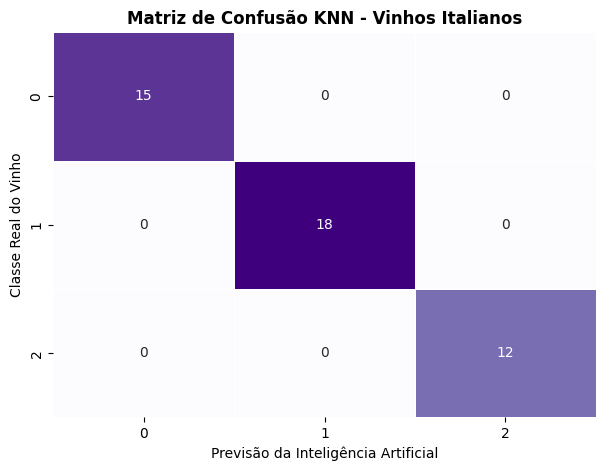

In [18]:
# ==============================================================================
# LABORATÓRIO: KNN - CLASSIFICAÇÃO DE VINHOS (DADOS REAIS)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("A carregar o dataset real de Vinhos Italianos...")

# 1. Carregar os dados nativos do scikit-learn
wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target, name='Tipo_Vinho')

print(f"Tamanho da Base: {X.shape[0]} registos e {X.shape[1]} características químicas.\n")

display(X.head(10))
display(y.head(10))

display(y.value_counts())

# 2. Separação de Treino e Teste (Estratificado para manter as 3 classes de vinho equilibradas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Escalonamento Numérico (Crucial para o KNN!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

display(X_train_scaled[ :5, : ])

# 4. Instanciar e Treinar o Modelo
print("A treinar o algoritmo KNN (Mapeando distâncias)...")
knn = KNeighborsClassifier(n_neighbors=15, metric='euclidean')#manhattan
knn.fit(X_train_scaled, y_train)

# 5. Fazer Previsões
previsoes_knn = knn.predict(X_test_scaled)

# 6. Avaliação Numérica
print("\nRelatório de Classificação (Tipos de Vinho: 0, 1 e 2):")
print(classification_report(y_test, previsoes_knn))

# 7. Matriz de Confusão
plt.figure(figsize=(7, 5))
matriz = confusion_matrix(y_test, previsoes_knn)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Purples', linewidths=0.5, cbar=False)
plt.title('Matriz de Confusão KNN - Vinhos Italianos', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real do Vinho', fontsize=10)
plt.xlabel('Previsão da Inteligência Artificial', fontsize=10)
plt.show()

In [17]:
from sklearn.model_selection import KFold, cross_val_score

print("\nRealizando Validação Cruzada (K-Fold) com 5 Folds...")

# Criar o objeto KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Re-instanciar o KNN para a validação cruzada
kf_knn = KNeighborsClassifier(n_neighbors=15, metric='euclidean')

# Realizar a validação cruzada e obter as pontuações de acurácia
scores = cross_val_score(kf_knn, X_train_scaled, y_train, cv=kf, scoring='accuracy')

print(f"Acurácias por fold: {scores}")
print(f"Acurácia média: {scores.mean():.4f}")
print(f"Desvio padrão da acurácia: {scores.std():.4f}")



Realizando Validação Cruzada (K-Fold) com 5 Folds...
Acurácias por fold: [1.         0.96296296 1.         0.96153846 0.92307692]
Acurácia média: 0.9695
Desvio padrão da acurácia: 0.0287



Testando o KNN para diferentes valores de K...


,K,Acurácia,Precisão (Macro),Recall (Macro)
0,1,0.955556,0.953526,0.962963
1,2,0.933333,0.935143,0.944444
2,3,0.955556,0.953526,0.962963
3,4,0.933333,0.931781,0.935185
4,5,0.933333,0.929110,0.935185
5,6,0.933333,0.931781,0.935185
6,7,0.977778,0.974359,0.981481
7,8,0.955556,0.960648,0.953704
8,9,0.977778,0.974359,0.981481
9,10,0.977778,0.974359,0.981481


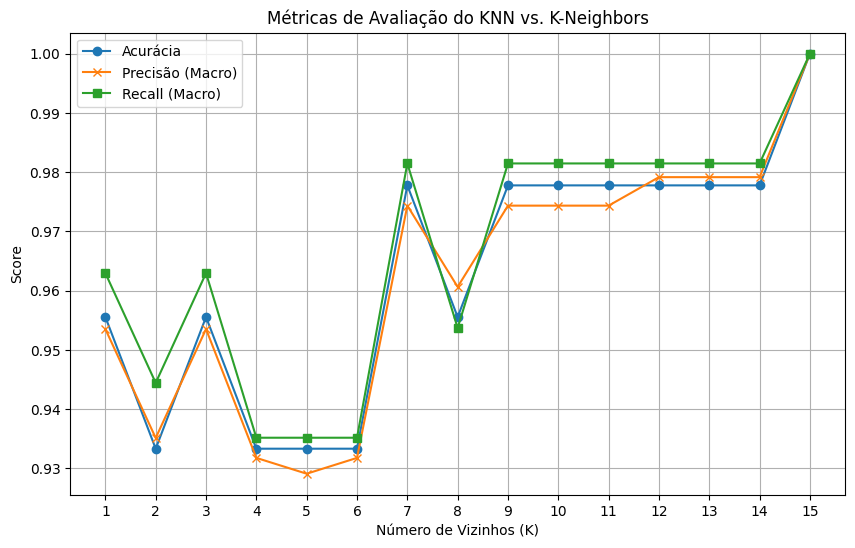

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracies = []
precisions = []
recalls = []
k_values = range(1, 16)

print("\nTestando o KNN para diferentes valores de K...")

for k in k_values:
    knn_loop = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_loop.fit(X_train_scaled, y_train)
    y_pred_loop = knn_loop.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_loop)
    prec = precision_score(y_test, y_pred_loop, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_loop, average='macro', zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

results_df = pd.DataFrame({
    'K': k_values,
    'Acurácia': accuracies,
    'Precisão (Macro)': precisions,
    'Recall (Macro)': recalls
})

display(results_df)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', label='Acurácia')
plt.plot(k_values, precisions, marker='x', label='Precisão (Macro)')
plt.plot(k_values, recalls, marker='s', label='Recall (Macro)')
plt.title('Métricas de Avaliação do KNN vs. K-Neighbors')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Score')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()


Executando K-Means nas características (sem o target y)...
Rótulos dos clusters gerados pelo K-Means:


,count
0,65
1,51
2,62



Silhouette Score para o K-Means: 0.2861

Visualizando os clusters com PCA...


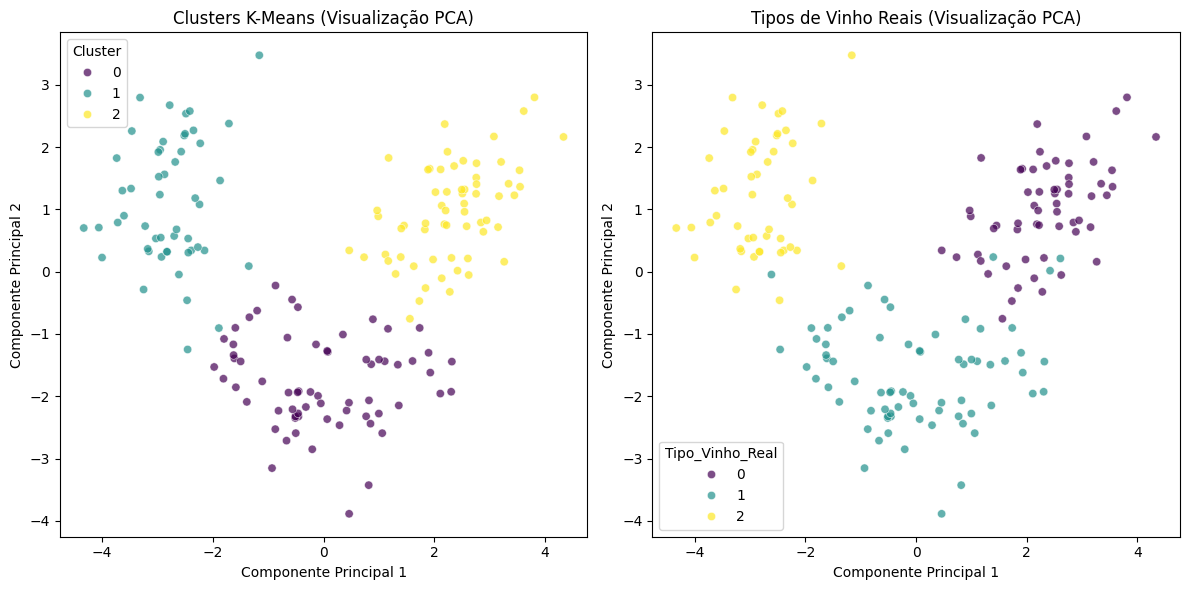

In [19]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("\nExecutando K-Means nas características (sem o target y)...")

# Escalonar todo o dataset X usando o scaler já treinado
X_scaled_full = scaler.transform(X)

# 1. Instanciar e Treinar o Modelo K-Means
# Assumimos 3 clusters, o número de classes de vinho conhecidas.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init para evitar inicializações ruins
kmeans.fit(X_scaled_full)

# 2. Obter os rótulos dos clusters
cluster_labels = kmeans.labels_
print("Rótulos dos clusters gerados pelo K-Means:")
display(pd.Series(cluster_labels).value_counts().sort_index())

# 3. Avaliação do Clustering (Silhoutte Score)
silhouette_avg = silhouette_score(X_scaled_full, cluster_labels)
print(f"\nSilhouette Score para o K-Means: {silhouette_avg:.4f}")

# 4. Visualização dos Clusters com PCA
print("\nVisualizando os clusters com PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = cluster_labels
pca_df['Tipo_Vinho_Real'] = y # Adicionar o tipo de vinho real para comparação

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    legend='full',
    alpha=0.7
)
plt.title('Clusters K-Means (Visualização PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.subplot(1, 2, 2)
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Tipo_Vinho_Real',
    palette='viridis',
    data=pca_df,
    legend='full',
    alpha=0.7
)
plt.title('Tipos de Vinho Reais (Visualização PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()